#### Loading dataset

In [1]:
# tensorflow_hub's hub.KerasLayer is a Keras 2 layer, but tf.keras here is
# Keras 3, so Sequential rejects it ("Only instances of `keras.Layer` can be
# added"). This makes tf.keras resolve to tf_keras (Keras 2) instead.
# MUST be set before importing tensorflow, hence the first two lines.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pylab as plt
import random

print("tf", tf.__version__, "| tf.keras ->", tf.keras.__name__)

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/51.TutGator.com-Linkedin-TensorFlow-Working-with-Images/.venv/lib/python3.13/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


tf 2.21.0 | tf.keras -> tensorflow.keras


In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 [==============================] - 2697s 16us/step


In [3]:
#Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

#### An overview of the images

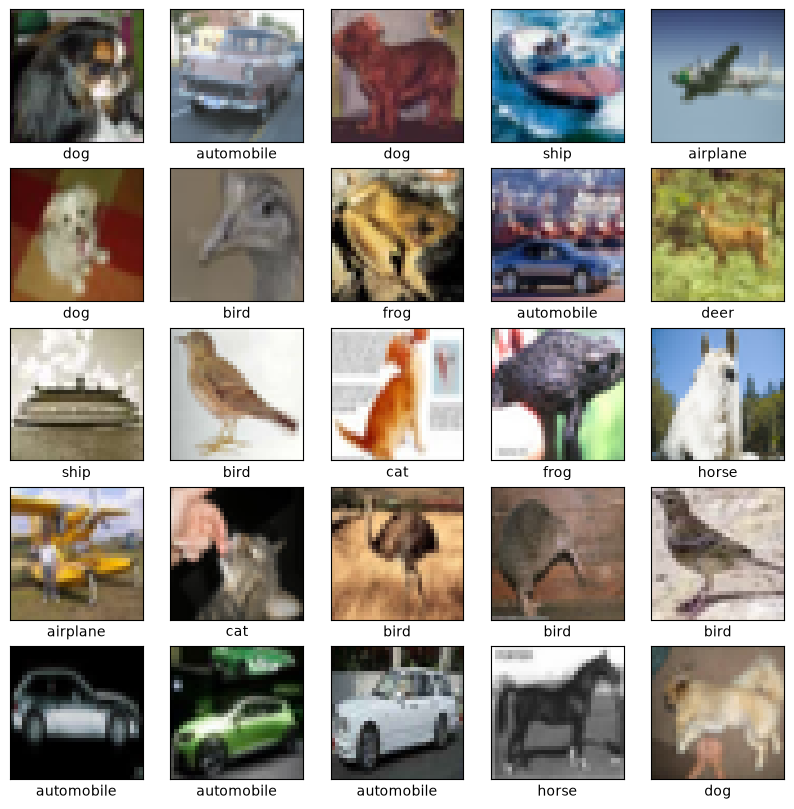

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

train_idx = list(range(len(train_labels)))

random.seed(1)
random_sample = random.sample(train_idx, 25)

plt.figure(figsize=(10,10))
for i in range(len(random_sample)):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[random_sample[i]], cmap=plt.cm.binary)
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[random_sample[i]][0]])
plt.show()

### Build, compile and train the model

In [5]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((test_images[:5000], test_labels[:5000]))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images[5000:], test_labels[5000:]))

TRAIN_DATASET_SIZE = len(train_dataset)
VALIDATION_DATASET_SIZE = len(validation_dataset)
TEST_DATASET_SIZE = len(test_dataset)

BATCH_SIZE = 128

train_dataset = train_dataset.shuffle(buffer_size=TRAIN_DATASET_SIZE).batch(BATCH_SIZE)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

In [6]:
#building the model
model_handle = 'https://tfhub.dev/deepmind/ganeval-cifar10-convnet/1'
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(32, 32)+ (3,)), # we can resize the images from 32*32 to 224*224 to get better accuracy, but we will keep it as it is for now
    hub.KerasLayer(model_handle, trainable=False)
])
model

In [7]:
#compiling the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# no training required 

_,accuracy = model.evaluate(test_dataset)
print(f"The model accuracy is: {accuracy*100:0.1f}%")

40/40 [==============================] - 8s 189ms/step - loss: 0.1986 - accuracy: 0.9454
The model accuracy is: 94.5%


Model accuracy is now

### Make Predictions

1/1 [==============================] - 0s 66ms/step
automobile


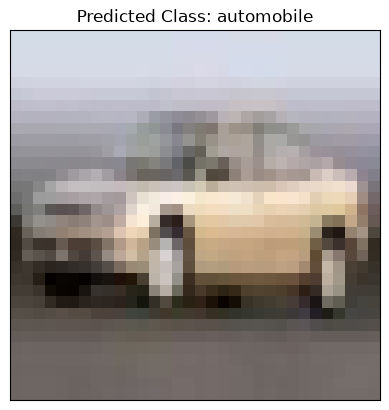

In [8]:
image_id = 7260 #pick an image id between 5000 and 9999 inclusive

def get_prediction(image_id):
    img = test_images[image_id]
    img = np.expand_dims(img, 0) # Create a batch
    pred = model.predict(img)
    pred = np.argmax(pred)
    print(class_names[pred])
    plt.figure()
    plt.imshow(test_images[image_id], cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Predicted Class: ' + class_names[pred])
    plt.show()
get_prediction(image_id)

Now, model correctly predicts that it is automobile

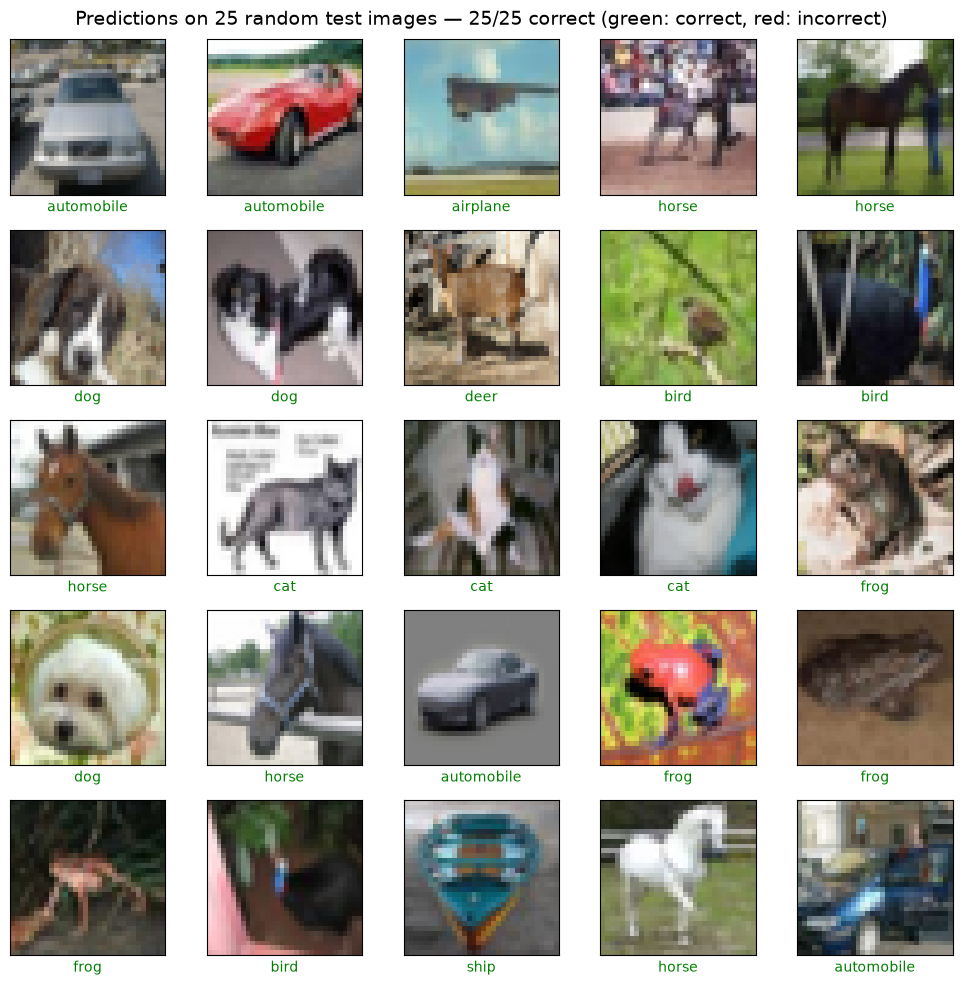

25/25 correct in this sample


In [10]:
test_idx = list(range(5000, 10000))

random.seed(1)
random_sample = random.sample(test_idx, 25)

# One batched predict instead of 25 single-image calls: identical results, much
# faster, and it avoids printing 25 separate progress bars.
batch = test_images[random_sample]                  # (25, 32, 32, 3)
pred_labels = np.argmax(model.predict(batch, verbose=0), axis=-1)

# The CIFAR labels are stored as arrays, which is why you need the extra index
true_labels = test_labels[random_sample][:, 0]

n_correct = int((pred_labels == true_labels).sum())

plt.figure(figsize=(10, 10))
for i in range(len(random_sample)):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[random_sample[i]], cmap=plt.cm.binary)
    ok = pred_labels[i] == true_labels[i]
    label = class_names[pred_labels[i]] if ok else \
        f"{class_names[pred_labels[i]]}\ntrue: {class_names[true_labels[i]]}"
    plt.xlabel(label, color="green" if ok else "red")

plt.suptitle(f"Predictions on 25 random test images — {n_correct}/25 correct "
             "(green: correct, red: incorrect)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"{n_correct}/25 correct in this sample")

It shows tensorflow hub can be used for image classification